# Pipeline HerbalScan — Klasifikasi Daun Herbal

Notebook ini menjalankan seluruh pipeline:
1. Remove background (rembg)
2. Resize 224×224
3. Augmentasi Flip (H + V) + Rotasi
4. Build dataset final (no-bg & bg)
5. Visualisasi sampel
6. **Eksperimen 1** — Gabungan BG + NoBG, **daun sehat saja** (16 kelas), split 80:20 & 70:30
7. **Eksperimen 2** — Gabungan BG + NoBG, **semua kondisi termasuk rusak** (32 kelas), split 80:20 & 70:30
8. Ringkasan hasil

**Struktur kelas**:
- Eksperimen 1: `"Daun X NoBG"` dan `"Daun X BG"` → 8 spesies × 2 = 16 kelas
- Eksperimen 2: `"Daun X NoBG"`, `"Daun X BG"`, `"Daun X Rusak NoBG"`, `"Daun X Rusak BG"` → 8 spesies × 2 kondisi × 2 background = 32 kelas

**Augmentasi offline**: 250 H-Flip + 250 V-Flip + 500 Rotasi (0°/90°/180°/270°, 125 per sudut) → 1000 augmented per kelas  
Total per kelas: 300 original + 1000 augmented = **1300 gambar**  
**Augmentasi training**: Rotasi kotak acak (0°/90°/180°/270°) + H-Flip + GaussianBlur(k=3)

In [1]:
import json, time, random, shutil
import cv2
import torch
import torch.nn as nn
import numpy as np
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from rembg import remove as rembg_remove
from torchvision import datasets, transforms, models
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix

BASE_DIR = Path().resolve()
if BASE_DIR.name == 'training':
    BASE_DIR = BASE_DIR.parent  
DATA_DIR      = BASE_DIR / "data"
NOBG_DIR      = DATA_DIR / "nobg"
RESIZED_DIR   = DATA_DIR / "resized"
AUGMENTED_DIR = DATA_DIR / "augmented"
FINAL_NOBG    = DATA_DIR / "final"
FINAL_BG      = DATA_DIR / "final bg"
MODEL_DIR     = BASE_DIR / "model"
RESULT_DIR    = BASE_DIR / "results"

BATCH_SIZE = 16
EPOCHS     = 100
LR         = 0.001
SEED       = 42
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for d in [MODEL_DIR, RESULT_DIR]:
    d.mkdir(exist_ok=True)

print(f"Device: {DEVICE}")

c:\Users\dvsw1\Documents\Kuliah\Kuliah\Skripsi\Code\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


## Transforms & Helper Functions

In [2]:
# ── Transforms ────────────────────────────────────────────────────────────────
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Lambda(lambda img: TF.rotate(img, random.choice([0, 90, 180, 270]))),
    transforms.RandomHorizontalFlip(),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])


# ── CombinedTaggedDataset ─────────────────────────────────────────────────────
class CombinedTaggedDataset(Dataset):
    def __init__(self, nobg_root: Path, bg_root: Path, include_rusak: bool = True):
        from torchvision.datasets import ImageFolder as _IF
        nobg_base = _IF(str(nobg_root))
        bg_base   = _IF(str(bg_root))

        nobg_tagged = {c: f"{c} NoBG" for c in nobg_base.classes}
        bg_tagged   = {c: f"{c} BG"   for c in bg_base.classes}

        all_class_names: list[str] = []
        for orig, tagged in nobg_tagged.items():
            if (include_rusak or "Rusak" not in orig) and tagged not in all_class_names:
                all_class_names.append(tagged)
        for orig, tagged in bg_tagged.items():
            if (include_rusak or "Rusak" not in orig) and tagged not in all_class_names:
                all_class_names.append(tagged)

        self.classes      = sorted(all_class_names)
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

        self.samples: list[tuple[str, int]] = []
        for img_path, orig_label in nobg_base.samples:
            tagged = nobg_tagged[nobg_base.classes[orig_label]]
            if tagged in self.class_to_idx:
                self.samples.append((img_path, self.class_to_idx[tagged]))
        for img_path, orig_label in bg_base.samples:
            tagged = bg_tagged[bg_base.classes[orig_label]]
            if tagged in self.class_to_idx:
                self.samples.append((img_path, self.class_to_idx[tagged]))

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int):
        img_path, label = self.samples[idx]
        return Image.open(img_path).convert("RGB"), label


# ── TransformWrapper ──────────────────────────────────────────────────────────
class TransformWrapper(Dataset):
    def __init__(self, subset: Subset, transform):
        self.subset    = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        return self.transform(img), label


# ── Helper confusion matrix per grup ─────────────────────────────────────────
def _species_name(class_name: str) -> str:
    return (class_name
            .replace(" Rusak NoBG", "").replace(" Rusak BG", "")
            .replace(" NoBG", "").replace(" BG", "")
            .replace(" Rusak", "").strip())

def _get_group(class_name: str) -> str:
    is_rusak = "Rusak" in class_name
    is_nobg  = class_name.endswith("NoBG")
    if   not is_rusak and not is_nobg: return "Sehat BG"
    elif not is_rusak and     is_nobg: return "Sehat NoBG"
    elif     is_rusak and not is_nobg: return "Rusak BG"
    else:                              return "Rusak NoBG"

def plot_split_cm(y_true, y_pred, class_names, exp_tag, train_pct, exp_label, label_str):
    group_of   = {cn: _get_group(cn) for cn in class_names}
    groups     = sorted(set(group_of.values()))
    n_groups   = len(groups)
    n_cols_fig = 2
    n_rows_fig = (n_groups + 1) // 2

    fig, axes = plt.subplots(n_rows_fig, n_cols_fig,
                             figsize=(n_cols_fig * 9, n_rows_fig * 7.5))
    axes = axes.flatten()

    for ax_idx, group in enumerate(groups):
        grp_classes  = [cn for cn in class_names if group_of[cn] == group]
        grp_idx_map  = {class_names.index(cn): i for i, cn in enumerate(grp_classes)}
        species_lbls = [_species_name(cn) for cn in grp_classes]
        n            = len(grp_classes)

        mask     = [i for i, t in enumerate(y_true) if t in grp_idx_map]
        sub_true = [grp_idx_map[y_true[i]] for i in mask]
        sub_pred = [grp_idx_map.get(y_pred[i], n) for i in mask]

        has_other = any(p == n for p in sub_pred)
        n_pred    = n + 1 if has_other else n
        col_lbls  = species_lbls + (["[Lainnya]"] if has_other else [])

        cm  = confusion_matrix(sub_true, sub_pred, labels=list(range(n_pred)))
        acc = sum(t == p for t, p in zip(sub_true, sub_pred)) / len(sub_true) if sub_true else 0

        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=col_lbls, yticklabels=species_lbls,
                    ax=axes[ax_idx], annot_kws={"size": 8})
        axes[ax_idx].set_title(f"{group}  |  Acc: {acc:.2%}", fontsize=11, fontweight="bold")
        axes[ax_idx].set_xlabel("Predicted", fontsize=9)
        axes[ax_idx].set_ylabel("True",      fontsize=9)
        axes[ax_idx].tick_params(axis="x", rotation=45, labelsize=8)
        axes[ax_idx].tick_params(axis="y", rotation=0,  labelsize=8)

    for ax_idx in range(n_groups, len(axes)):
        axes[ax_idx].set_visible(False)

    fig.suptitle(f"Confusion Matrix per Grup — {exp_label}\nSplit {label_str}", fontsize=13)
    plt.tight_layout()
    plt.savefig(RESULT_DIR / f"cm_split_{exp_tag}_{train_pct}.png", dpi=150, bbox_inches="tight")
    plt.show()


def folder_ready(path: Path, min_files: int = 1) -> bool:
    return path.exists() and sum(1 for _ in path.rglob("*") if _.is_file()) >= min_files

print("Transforms & helpers siap.")


Transforms & helpers siap.


## 1. Remove Background (rembg)

In [3]:
if folder_ready(NOBG_DIR):
    print(f"Skip — {NOBG_DIR} sudah ada.")
else:
    NOBG_DIR.mkdir(parents=True, exist_ok=True)
    raw_dir = DATA_DIR / "raw"
    exts = {".jpg", ".jpeg", ".png"}
    total = 0
    for cls_dir in sorted(raw_dir.iterdir()):
        if not cls_dir.is_dir():
            continue
        out_cls = NOBG_DIR / cls_dir.name
        out_cls.mkdir(exist_ok=True)
        for img_file in cls_dir.iterdir():
            if img_file.suffix.lower() not in exts:
                continue
            with open(img_file, "rb") as f:
                result = rembg_remove(f.read())
            out_path = out_cls / (img_file.stem + ".png")
            out_path.write_bytes(result)
            total += 1
    print(f"Remove background selesai — {total} gambar → {NOBG_DIR}")

Skip — C:\Users\dvsw1\Documents\Kuliah\Kuliah\Skripsi\Code\data\nobg sudah ada.


## 2. Resize 224×224

In [4]:
if folder_ready(RESIZED_DIR):
    print(f"Skip — {RESIZED_DIR} sudah ada.")
else:
    RESIZED_DIR.mkdir(parents=True, exist_ok=True)
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    total = 0
    for cls_dir in sorted(NOBG_DIR.iterdir()):
        if not cls_dir.is_dir():
            continue
        out_cls = RESIZED_DIR / cls_dir.name
        out_cls.mkdir(exist_ok=True)
        for img_file in cls_dir.iterdir():
            if img_file.suffix.lower() not in exts:
                continue
            img = cv2.imread(str(img_file), cv2.IMREAD_UNCHANGED)
            if img is None:
                continue
            img_resized = cv2.resize(img, (224, 224))
            cv2.imwrite(str(out_cls / img_file.name), img_resized)
            total += 1
    print(f"Resize selesai — {total} gambar → {RESIZED_DIR}")

Skip — C:\Users\dvsw1\Documents\Kuliah\Kuliah\Skripsi\Code\data\resized sudah ada.


## 3. Augmentasi (Flip + Rotasi)

In [5]:
if folder_ready(AUGMENTED_DIR):
    print(f"Skip — {AUGMENTED_DIR} sudah ada.")
else:
    AUGMENTED_DIR.mkdir(parents=True, exist_ok=True)
    AUG_H_FLIP    = 250
    AUG_V_FLIP    = 250
    ROTATE_ANGLES = [0, 90, 180, 270]
    ROT_PER_ANGLE = 125
    exts = {".jpg", ".jpeg", ".png"}
    total = 0

    def _rotate(img, angle):
        if angle == 0:
            return img.copy()
        h, w = img.shape[:2]
        M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
        return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)

    for cls_dir in sorted(RESIZED_DIR.iterdir()):
        if not cls_dir.is_dir():
            continue
        out_cls = AUGMENTED_DIR / cls_dir.name
        out_cls.mkdir(exist_ok=True)
        images = [p for p in cls_dir.iterdir() if p.suffix.lower() in exts]
        if not images:
            continue

        # Tahap 1: Flip dari gambar original resized
        flipped_paths = []

        for i in range(AUG_H_FLIP):
            img = cv2.imread(str(random.choice(images)))
            if img is not None:
                out_path = out_cls / f"{cls_dir.name}_hflip_{i}.jpg"
                cv2.imwrite(str(out_path), cv2.flip(img, 1))
                flipped_paths.append(out_path)
                total += 1

        for i in range(AUG_V_FLIP):
            img = cv2.imread(str(random.choice(images)))
            if img is not None:
                out_path = out_cls / f"{cls_dir.name}_vflip_{i}.jpg"
                cv2.imwrite(str(out_path), cv2.flip(img, 0))
                flipped_paths.append(out_path)
                total += 1

        # Tahap 2: Rotasi dari gambar hasil flip (4 sudut x 125 = 500)
        rot_idx = 0
        for angle in ROTATE_ANGLES:
            for i in range(ROT_PER_ANGLE):
                img = cv2.imread(str(random.choice(flipped_paths)))
                if img is not None:
                    out_path = out_cls / f"{cls_dir.name}_rot{angle}_{rot_idx}.jpg"
                    cv2.imwrite(str(out_path), _rotate(img, angle))
                    rot_idx += 1
                    total += 1

        flip_total = AUG_H_FLIP + AUG_V_FLIP
        rot_total  = len(ROTATE_ANGLES) * ROT_PER_ANGLE
        print(f"  {cls_dir.name}: {flip_total} flip + {rot_total} rotasi = {flip_total + rot_total} augmented")

    print(f"Augmentasi selesai — {total} gambar → {AUGMENTED_DIR}")
    print(f"Per kelas: 300 original + 500 flip + 500 rotasi = 1300 total")

Skip — C:\Users\dvsw1\Documents\Kuliah\Kuliah\Skripsi\Code\data\augmented sudah ada.


## 4. Build Final Dataset (No-BG & BG)

Menggabungkan `data/resized` + `data/augmented` → `data/final` (no-bg)
Dataset `data/final bg` diasumsikan sudah tersedia (gambar asli dengan background).

In [6]:
def build_nobg_final():
    if folder_ready(FINAL_NOBG):
        print(f"Skip — {FINAL_NOBG} sudah ada.")
        return
    FINAL_NOBG.mkdir(parents=True, exist_ok=True)
    sources = [RESIZED_DIR, AUGMENTED_DIR]
    total = 0
    for src in sources:
        if not src.exists():
            print(f"  Warning: {src} tidak ditemukan, dilewati")
            continue
        for cls_dir in sorted(src.iterdir()):
            if not cls_dir.is_dir():
                continue
            out_cls = FINAL_NOBG / cls_dir.name
            out_cls.mkdir(exist_ok=True)
            for img_file in cls_dir.iterdir():
                if img_file.is_file():
                    dst = out_cls / f"{src.name}_{img_file.name}"
                    shutil.copy2(img_file, dst)
                    total += 1
    print(f"Build final no-bg selesai — {total} file → {FINAL_NOBG}")

build_nobg_final()

Skip — C:\Users\dvsw1\Documents\Kuliah\Kuliah\Skripsi\Code\data\final sudah ada.


## 5. Eksperimen 1 — Gabungan BG + NoBG (Daun Sehat Saja)

Menggabungkan dataset `data/final` (NoBG) dan `data/final bg` (BG).
Kelas **Rusak dikecualikan** — hanya daun sehat yang dilatih.
Nama kelas diberi tag: *"Daun X NoBG"* dan *"Daun X BG"* → **16 kelas** (8 spesies × 2 background).
Split: 80:20 dan 70:30 (Stratified Shuffle Split).


EKSPERIMEN 1 — SEHAT (BG + NOBG) | Split 80:20
Kelas: 16 | Train: 16640 | Val: 4160
  Epoch 1/100  train_loss=2.0057  train_acc=0.8004  val_loss=1.5587  val_acc=0.8938
  Epoch 2/100  train_loss=1.1554  train_acc=0.9694  val_loss=1.0210  val_acc=0.9440
  Epoch 3/100  train_loss=0.7575  train_acc=0.9794  val_loss=0.7575  val_acc=0.9623
  Epoch 4/100  train_loss=0.5394  train_acc=0.9850  val_loss=0.5514  val_acc=0.9793
  Epoch 5/100  train_loss=0.4082  train_acc=0.9882  val_loss=0.4587  val_acc=0.9786
  Epoch 6/100  train_loss=0.3182  train_acc=0.9907  val_loss=0.3633  val_acc=0.9796
  Epoch 7/100  train_loss=0.2561  train_acc=0.9922  val_loss=0.3088  val_acc=0.9844
  Epoch 8/100  train_loss=0.2107  train_acc=0.9942  val_loss=0.2454  val_acc=0.9913
  Epoch 9/100  train_loss=0.1792  train_acc=0.9934  val_loss=0.2267  val_acc=0.9925
  Epoch 10/100  train_loss=0.1485  train_acc=0.9963  val_loss=0.1950  val_acc=0.9947
  Epoch 11/100  train_loss=0.1279  train_acc=0.9948  val_loss=0.1552  val_

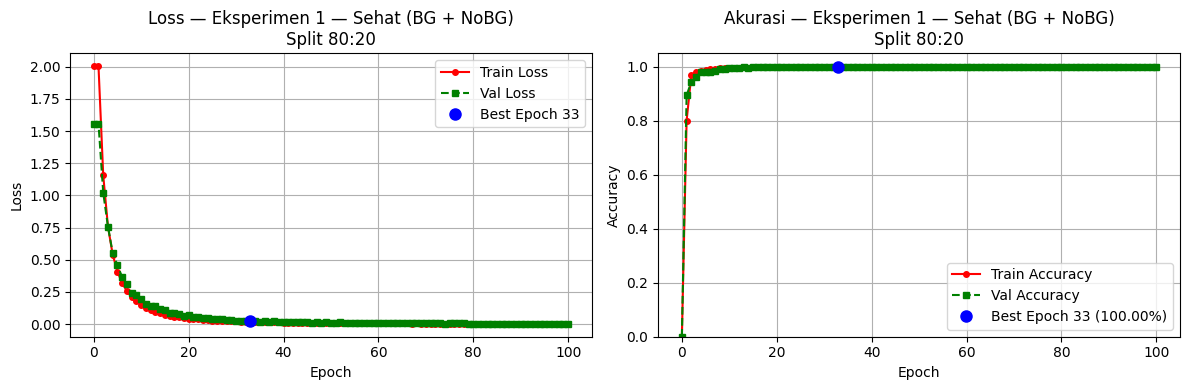

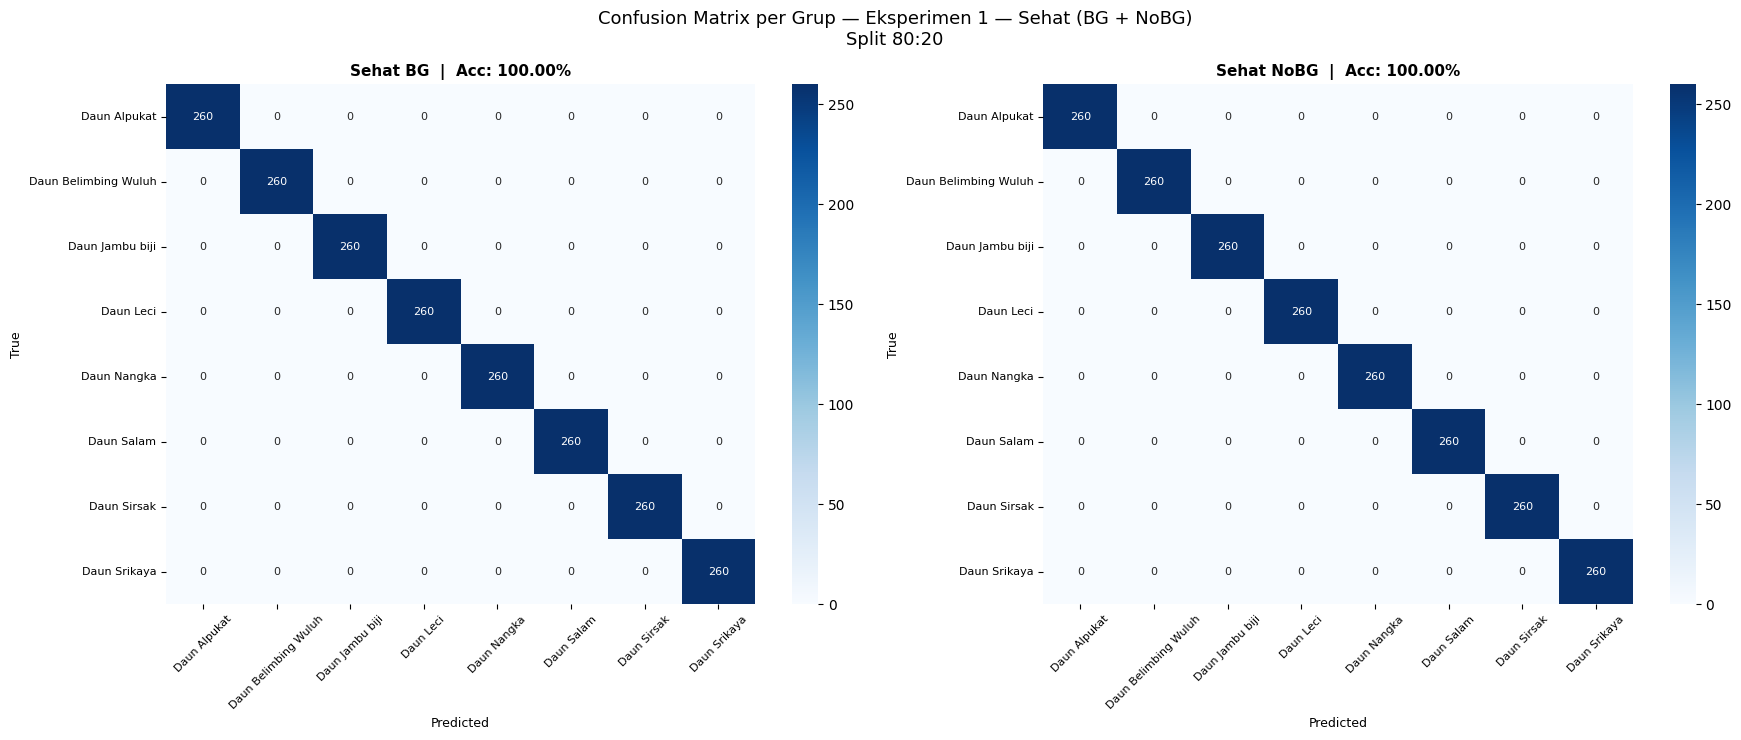

  Saved -> results_exp1_80.json

EKSPERIMEN 1 — SEHAT (BG + NOBG) | Split 70:30
Kelas: 16 | Train: 14560 | Val: 6240
  Epoch 1/100  train_loss=2.0659  train_acc=0.7984  val_loss=1.6163  val_acc=0.9290
  Epoch 2/100  train_loss=1.2464  train_acc=0.9650  val_loss=1.1175  val_acc=0.9471
  Epoch 3/100  train_loss=0.8451  train_acc=0.9798  val_loss=0.8787  val_acc=0.9481
  Epoch 4/100  train_loss=0.6139  train_acc=0.9813  val_loss=0.6387  val_acc=0.9705
  Epoch 5/100  train_loss=0.4706  train_acc=0.9867  val_loss=0.5120  val_acc=0.9779
  Epoch 6/100  train_loss=0.3725  train_acc=0.9894  val_loss=0.4174  val_acc=0.9803
  Epoch 7/100  train_loss=0.3043  train_acc=0.9922  val_loss=0.3555  val_acc=0.9837
  Epoch 8/100  train_loss=0.2542  train_acc=0.9927  val_loss=0.3031  val_acc=0.9873
  Epoch 9/100  train_loss=0.2109  train_acc=0.9941  val_loss=0.2801  val_acc=0.9899
  Epoch 10/100  train_loss=0.1808  train_acc=0.9951  val_loss=0.2277  val_acc=0.9907
  Epoch 11/100  train_loss=0.1548  train_a

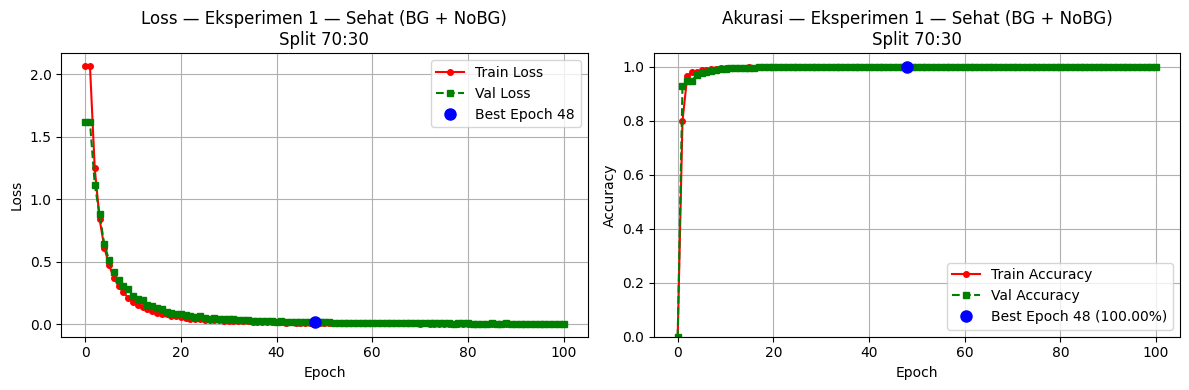

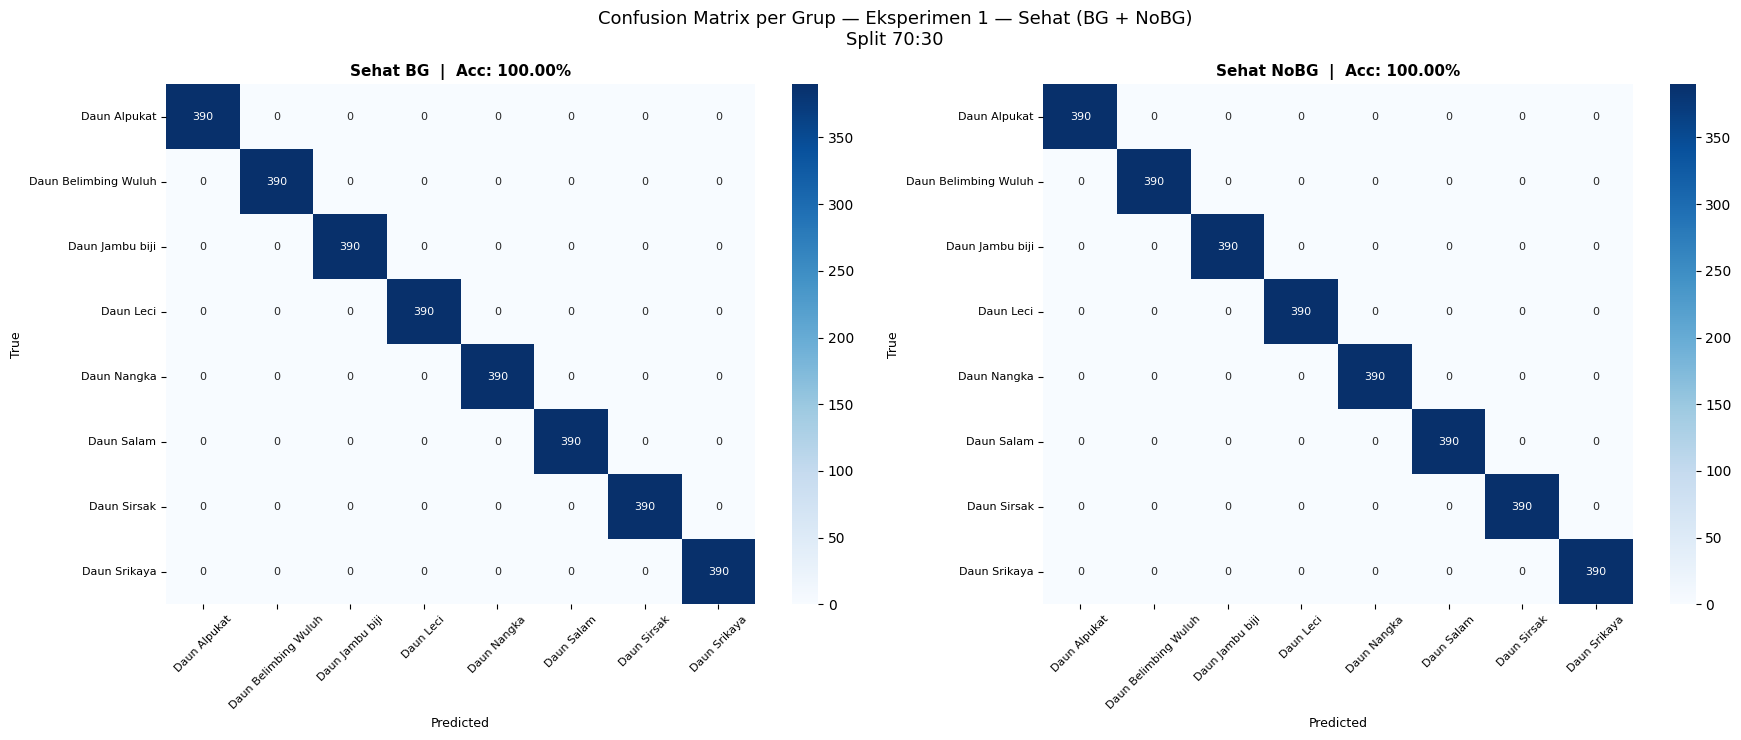

  Saved -> results_exp1_70.json


In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def train_and_evaluate(
    exp_tag: str,
    exp_label: str,
    include_rusak: bool,
    split_ratio: float,
):
    test_ratio = round(1.0 - split_ratio, 10)
    train_pct  = round(split_ratio * 100)
    test_pct   = 100 - train_pct
    label_str  = f"{train_pct}:{test_pct}"

    full_ds     = CombinedTaggedDataset(FINAL_NOBG, FINAL_BG, include_rusak=include_rusak)
    class_names = full_ds.classes
    num_classes = len(class_names)
    all_labels  = np.array([lbl for _, lbl in full_ds.samples])

    splitter = StratifiedShuffleSplit(n_splits=1, test_size=test_ratio, random_state=SEED)
    train_idx, val_idx = next(splitter.split(np.zeros(len(all_labels)), all_labels))

    train_loader = DataLoader(
        TransformWrapper(Subset(full_ds, train_idx), transform_train),
        batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
    )
    val_loader = DataLoader(
        TransformWrapper(Subset(full_ds, val_idx), transform_val),
        batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
    )

    print(f"\n{'='*60}")
    print(f"{exp_label.upper()} | Split {label_str}")
    print(f"Kelas: {num_classes} | Train: {len(train_idx)} | Val: {len(val_idx)}")

    model = models.shufflenet_v2_x1_0(
        weights=models.ShuffleNet_V2_X1_0_Weights.IMAGENET1K_V1
    )
    for p in model.parameters():
        p.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    model.to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.fc.parameters(), lr=LR)

    history = []
    start   = time.time()

    for epoch in range(EPOCHS):
        model.train()
        running_loss, train_correct, train_total = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            out  = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            running_loss  += loss.item()
            _, preds       = torch.max(out, 1)
            train_correct += (preds == y).sum().item()
            train_total   += y.size(0)
        avg_loss  = running_loss / len(train_loader)
        train_acc = train_correct / train_total

        model.eval()
        correct, total, val_loss = 0, 0, 0.0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                out      = model(x)
                val_loss += criterion(out, y).item()
                _, preds  = torch.max(out, 1)
                correct  += (preds == y).sum().item()
                total    += y.size(0)
        val_acc      = correct / total
        avg_val_loss = val_loss / len(val_loader)

        history.append({
            "epoch":      epoch + 1,
            "train_loss": round(avg_loss, 4),
            "train_acc":  round(train_acc, 4),
            "val_loss":   round(avg_val_loss, 4),
            "val_acc":    round(val_acc, 4),
        })
        print(f"  Epoch {epoch+1}/{EPOCHS}  train_loss={avg_loss:.4f}  train_acc={train_acc:.4f}"
              f"  val_loss={avg_val_loss:.4f}  val_acc={val_acc:.4f}")

    elapsed = time.time() - start
    print(f"  Selesai dalam {int(elapsed//60)}m {int(elapsed%60)}s")

    # ── Evaluasi akhir ────────────────────────────────────────────────────────
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in val_loader:
            _, preds = torch.max(model(x.to(DEVICE)), 1)
            y_true.extend(y.numpy())
            y_pred.extend(preds.cpu().numpy())

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1   = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

    print(f"\n  {'Metric':<12} {'Score':>8}")
    print(f"  {'-'*22}")
    print(f"  {'Accuracy':<12} {acc:>8.4f}")
    print(f"  {'Precision':<12} {prec:>8.4f}")
    print(f"  {'Recall':<12} {rec:>8.4f}")
    print(f"  {'F1-Score':<12} {f1:>8.4f}")

    best = max(history, key=lambda h: h["val_acc"])

    # ── Plot loss & akurasi ───────────────────────────────────────────────────
    ep_plot         = [0] + [h["epoch"]      for h in history]
    train_loss_plot = [history[0]["train_loss"]] + [h["train_loss"] for h in history]
    val_loss_plot   = [history[0]["val_loss"]]   + [h["val_loss"]   for h in history]
    train_acc_plot  = [0] + [h["train_acc"] for h in history]
    val_acc_plot    = [0] + [h["val_acc"]   for h in history]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(ep_plot, train_loss_plot, "r-o",  markersize=4, label="Train Loss")
    ax1.plot(ep_plot, val_loss_plot,   "g--s", markersize=4, label="Val Loss")
    ax1.plot(best["epoch"], best["val_loss"], "bo", markersize=8,
             label=f"Best Epoch {best['epoch']}")
    ax1.set_title(f"Loss — {exp_label}\nSplit {label_str}")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.legend(); ax1.grid(True)

    ax2.plot(ep_plot, train_acc_plot, "r-o",  markersize=4, label="Train Accuracy")
    ax2.plot(ep_plot, val_acc_plot,   "g--s", markersize=4, label="Val Accuracy")
    ax2.plot(best["epoch"], best["val_acc"], "bo", markersize=8,
             label=f"Best Epoch {best['epoch']} ({best['val_acc']:.2%})")
    ax2.set_title(f"Akurasi — {exp_label}\nSplit {label_str}")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
    ax2.set_ylim(0, 1.05)
    ax2.legend(); ax2.grid(True)

    plt.tight_layout()
    plt.savefig(RESULT_DIR / f"plot_{exp_tag}_{train_pct}.png", dpi=120, bbox_inches="tight")
    plt.show()

    # ── Confusion matrix terpisah per grup ───────────────────────────────────
    plot_split_cm(y_true, y_pred, class_names,
                  exp_tag, train_pct, exp_label, label_str)

    # ── Simpan model & JSON (UTF-8) ───────────────────────────────────────────
    torch.save(model.state_dict(), MODEL_DIR / f"shufflenet_{exp_tag}_{train_pct}.pth")
    json_path = RESULT_DIR / f"results_{exp_tag}_{train_pct}.json"
    json_path.write_text(json.dumps({
        "experiment":            exp_label,
        "tag":                   exp_tag,
        "split":                 label_str,
        "dataset_nobg":          str(FINAL_NOBG),
        "dataset_bg":            str(FINAL_BG),
        "include_rusak":         include_rusak,
        "num_classes":           num_classes,
        "class_names":           class_names,
        "epochs":                EPOCHS,
        "training_time_sec":     round(elapsed, 2),
        "accuracy":              round(acc, 4),
        "precision_weighted":    round(prec, 4),
        "recall_weighted":       round(rec, 4),
        "f1_weighted":           round(f1, 4),
        "best_epoch":            best["epoch"],
        "best_val_accuracy":     best["val_acc"],
        "final_train_accuracy":  history[-1]["train_acc"],
        "final_val_accuracy":    history[-1]["val_acc"],
        "classification_report": report,
        "training_history":      history,
    }, indent=2, ensure_ascii=False), encoding="utf-8")
    print(f"  Saved -> {json_path.name}")


# Jalankan Eksperimen 1 (sehat saja)
for ratio in [0.8, 0.7]:
    train_and_evaluate(
        exp_tag="exp1",
        exp_label="Eksperimen 1 — Sehat (BG + NoBG)",
        include_rusak=False,
        split_ratio=ratio,
    )


## 6. Eksperimen 2 — Gabungan BG + NoBG (Semua Kondisi: Sehat + Rusak)

Menggabungkan dataset `data/final` (NoBG) dan `data/final bg` (BG).
**Semua kelas dilatih**, termasuk daun rusak.
Nama kelas: *"Daun X BG"*, *"Daun X NoBG"*, *"Daun X Rusak BG"*, *"Daun X Rusak NoBG"* → **32 kelas**.
Confusion matrix menampilkan label rusak secara terpisah berdasarkan kondisi background.


EKSPERIMEN 2 — SEMUA KONDISI (BG + NOBG + RUSAK) | Split 80:20
Kelas: 32 | Train: 33280 | Val: 8320
  Epoch 1/100  train_loss=2.2828  train_acc=0.8139  val_loss=1.6604  val_acc=0.9081
  Epoch 2/100  train_loss=1.1566  train_acc=0.9623  val_loss=1.0520  val_acc=0.9431
  Epoch 3/100  train_loss=0.7077  train_acc=0.9789  val_loss=0.7158  val_acc=0.9624
  Epoch 4/100  train_loss=0.4823  train_acc=0.9850  val_loss=0.5520  val_acc=0.9716
  Epoch 5/100  train_loss=0.3503  train_acc=0.9882  val_loss=0.4229  val_acc=0.9774
  Epoch 6/100  train_loss=0.2668  train_acc=0.9895  val_loss=0.3428  val_acc=0.9809
  Epoch 7/100  train_loss=0.2094  train_acc=0.9924  val_loss=0.2732  val_acc=0.9868
  Epoch 8/100  train_loss=0.1697  train_acc=0.9929  val_loss=0.2304  val_acc=0.9906
  Epoch 9/100  train_loss=0.1391  train_acc=0.9937  val_loss=0.1804  val_acc=0.9929
  Epoch 10/100  train_loss=0.1168  train_acc=0.9951  val_loss=0.1518  val_acc=0.9936
  Epoch 11/100  train_loss=0.0996  train_acc=0.9953  val_l

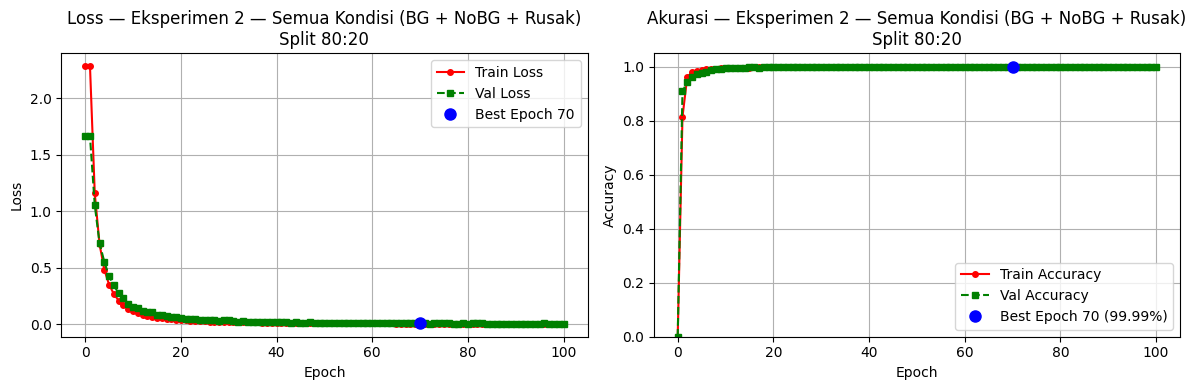

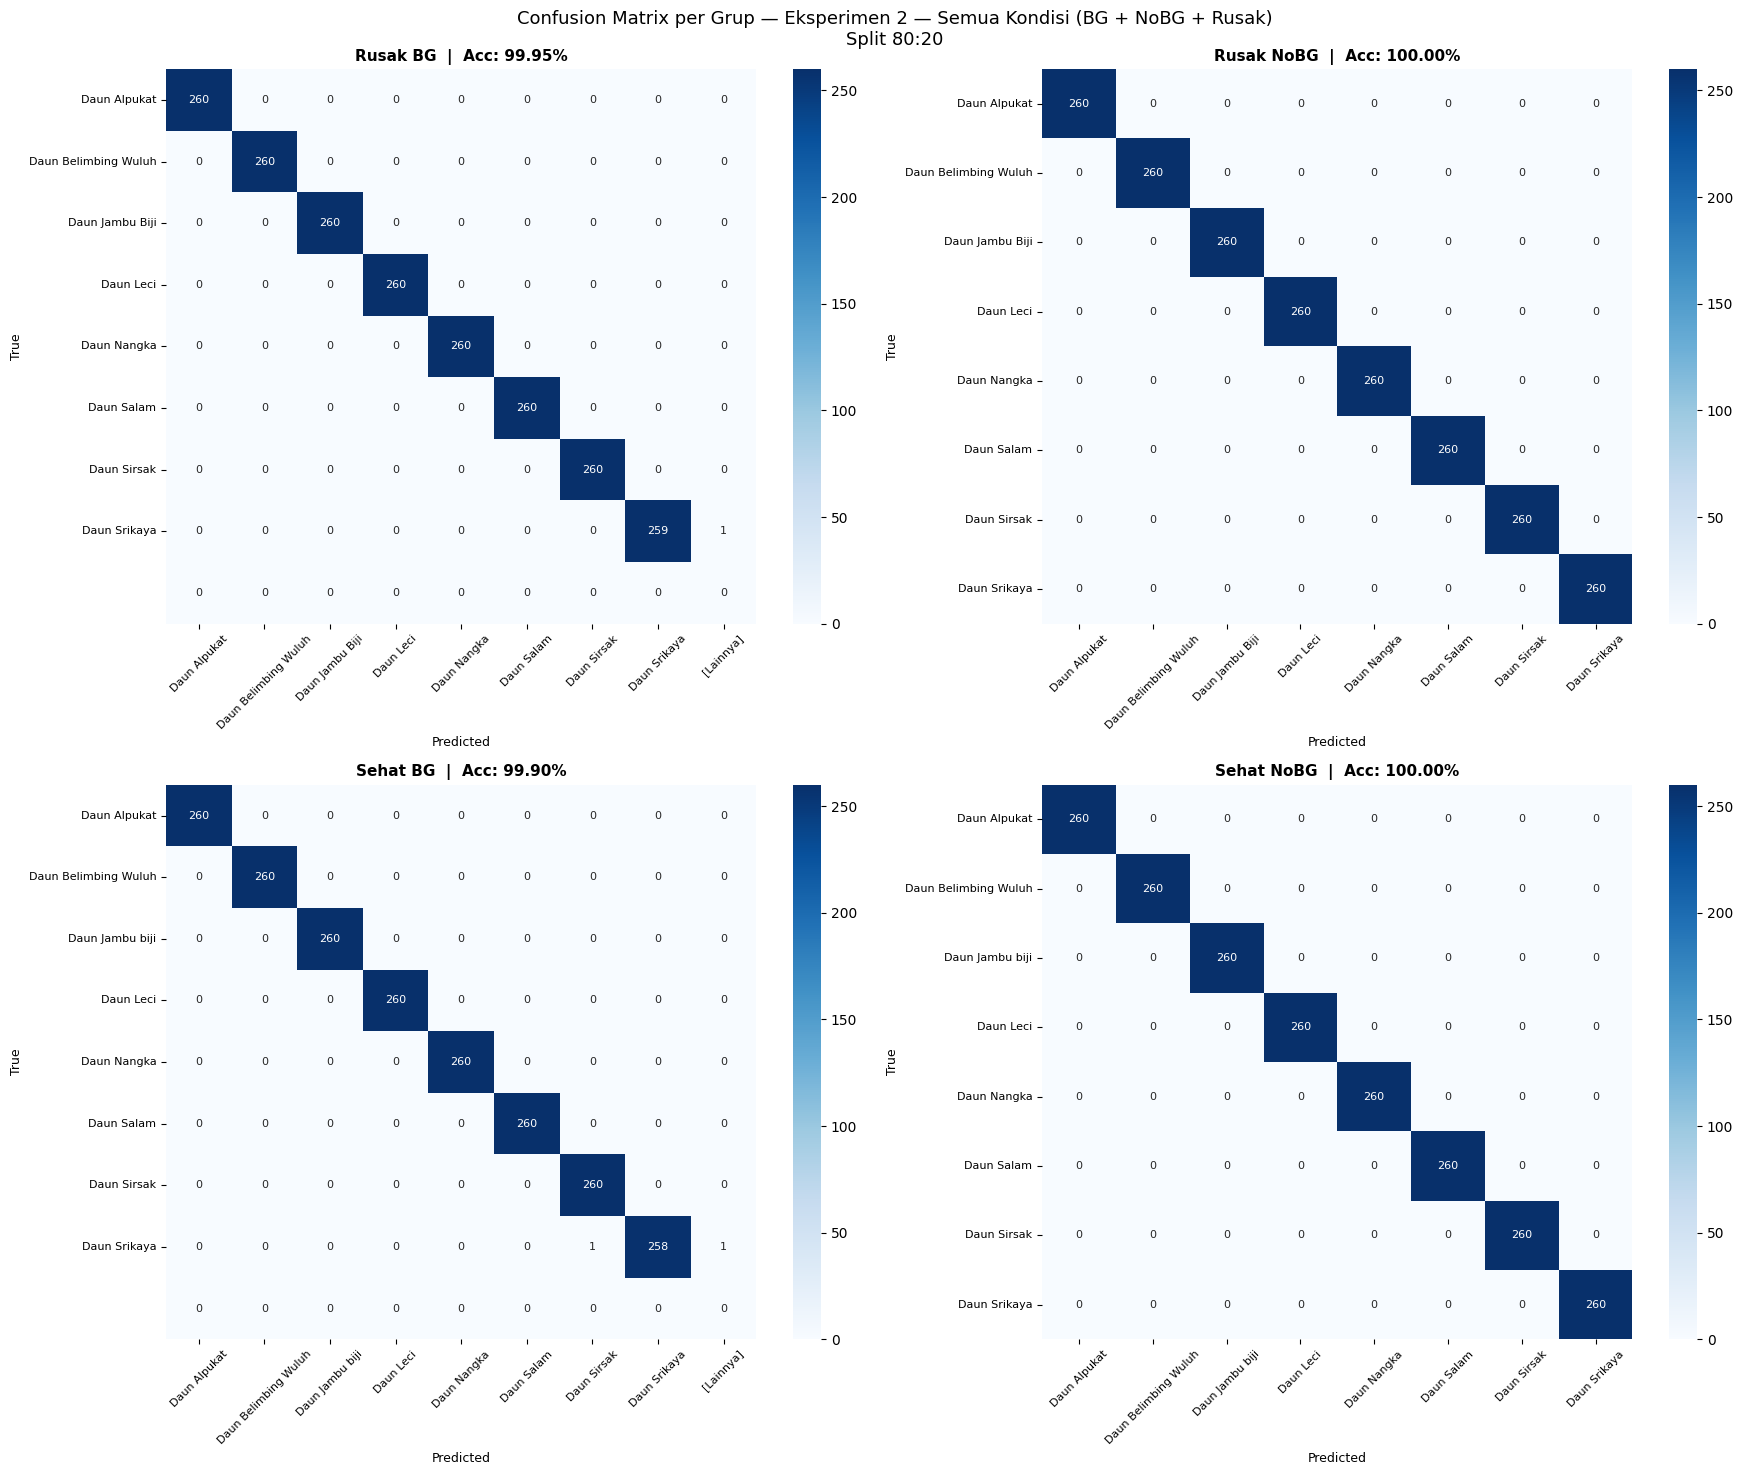

  Saved -> results_exp2_80.json

EKSPERIMEN 2 — SEMUA KONDISI (BG + NOBG + RUSAK) | Split 70:30
Kelas: 32 | Train: 29120 | Val: 12480
  Epoch 1/100  train_loss=2.3802  train_acc=0.8025  val_loss=1.7778  val_acc=0.9052
  Epoch 2/100  train_loss=1.2774  train_acc=0.9583  val_loss=1.1640  val_acc=0.9288
  Epoch 3/100  train_loss=0.8094  train_acc=0.9749  val_loss=0.7863  val_acc=0.9545
  Epoch 4/100  train_loss=0.5639  train_acc=0.9843  val_loss=0.6189  val_acc=0.9653
  Epoch 5/100  train_loss=0.4181  train_acc=0.9855  val_loss=0.5176  val_acc=0.9704
  Epoch 6/100  train_loss=0.3214  train_acc=0.9876  val_loss=0.3787  val_acc=0.9825
  Epoch 7/100  train_loss=0.2539  train_acc=0.9901  val_loss=0.3011  val_acc=0.9853
  Epoch 8/100  train_loss=0.2057  train_acc=0.9920  val_loss=0.2515  val_acc=0.9898
  Epoch 9/100  train_loss=0.1722  train_acc=0.9926  val_loss=0.2400  val_acc=0.9909
  Epoch 10/100  train_loss=0.1430  train_acc=0.9949  val_loss=0.1824  val_acc=0.9930
  Epoch 11/100  train_los

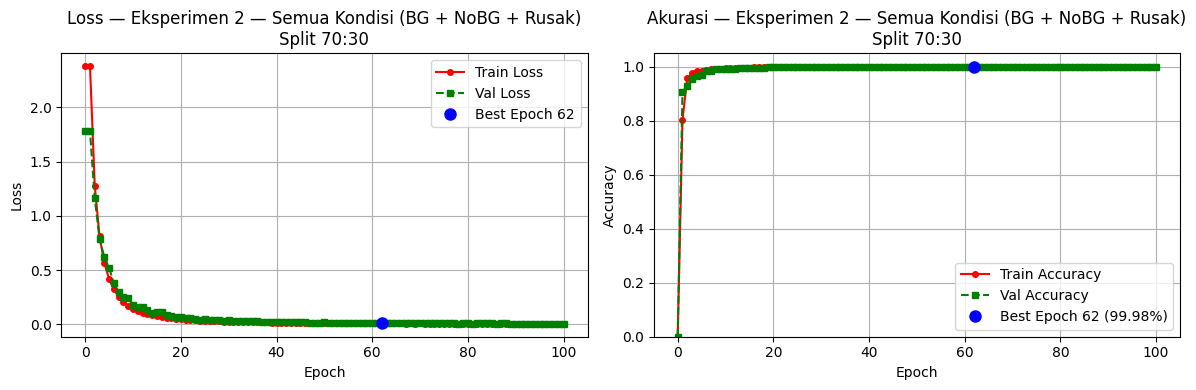

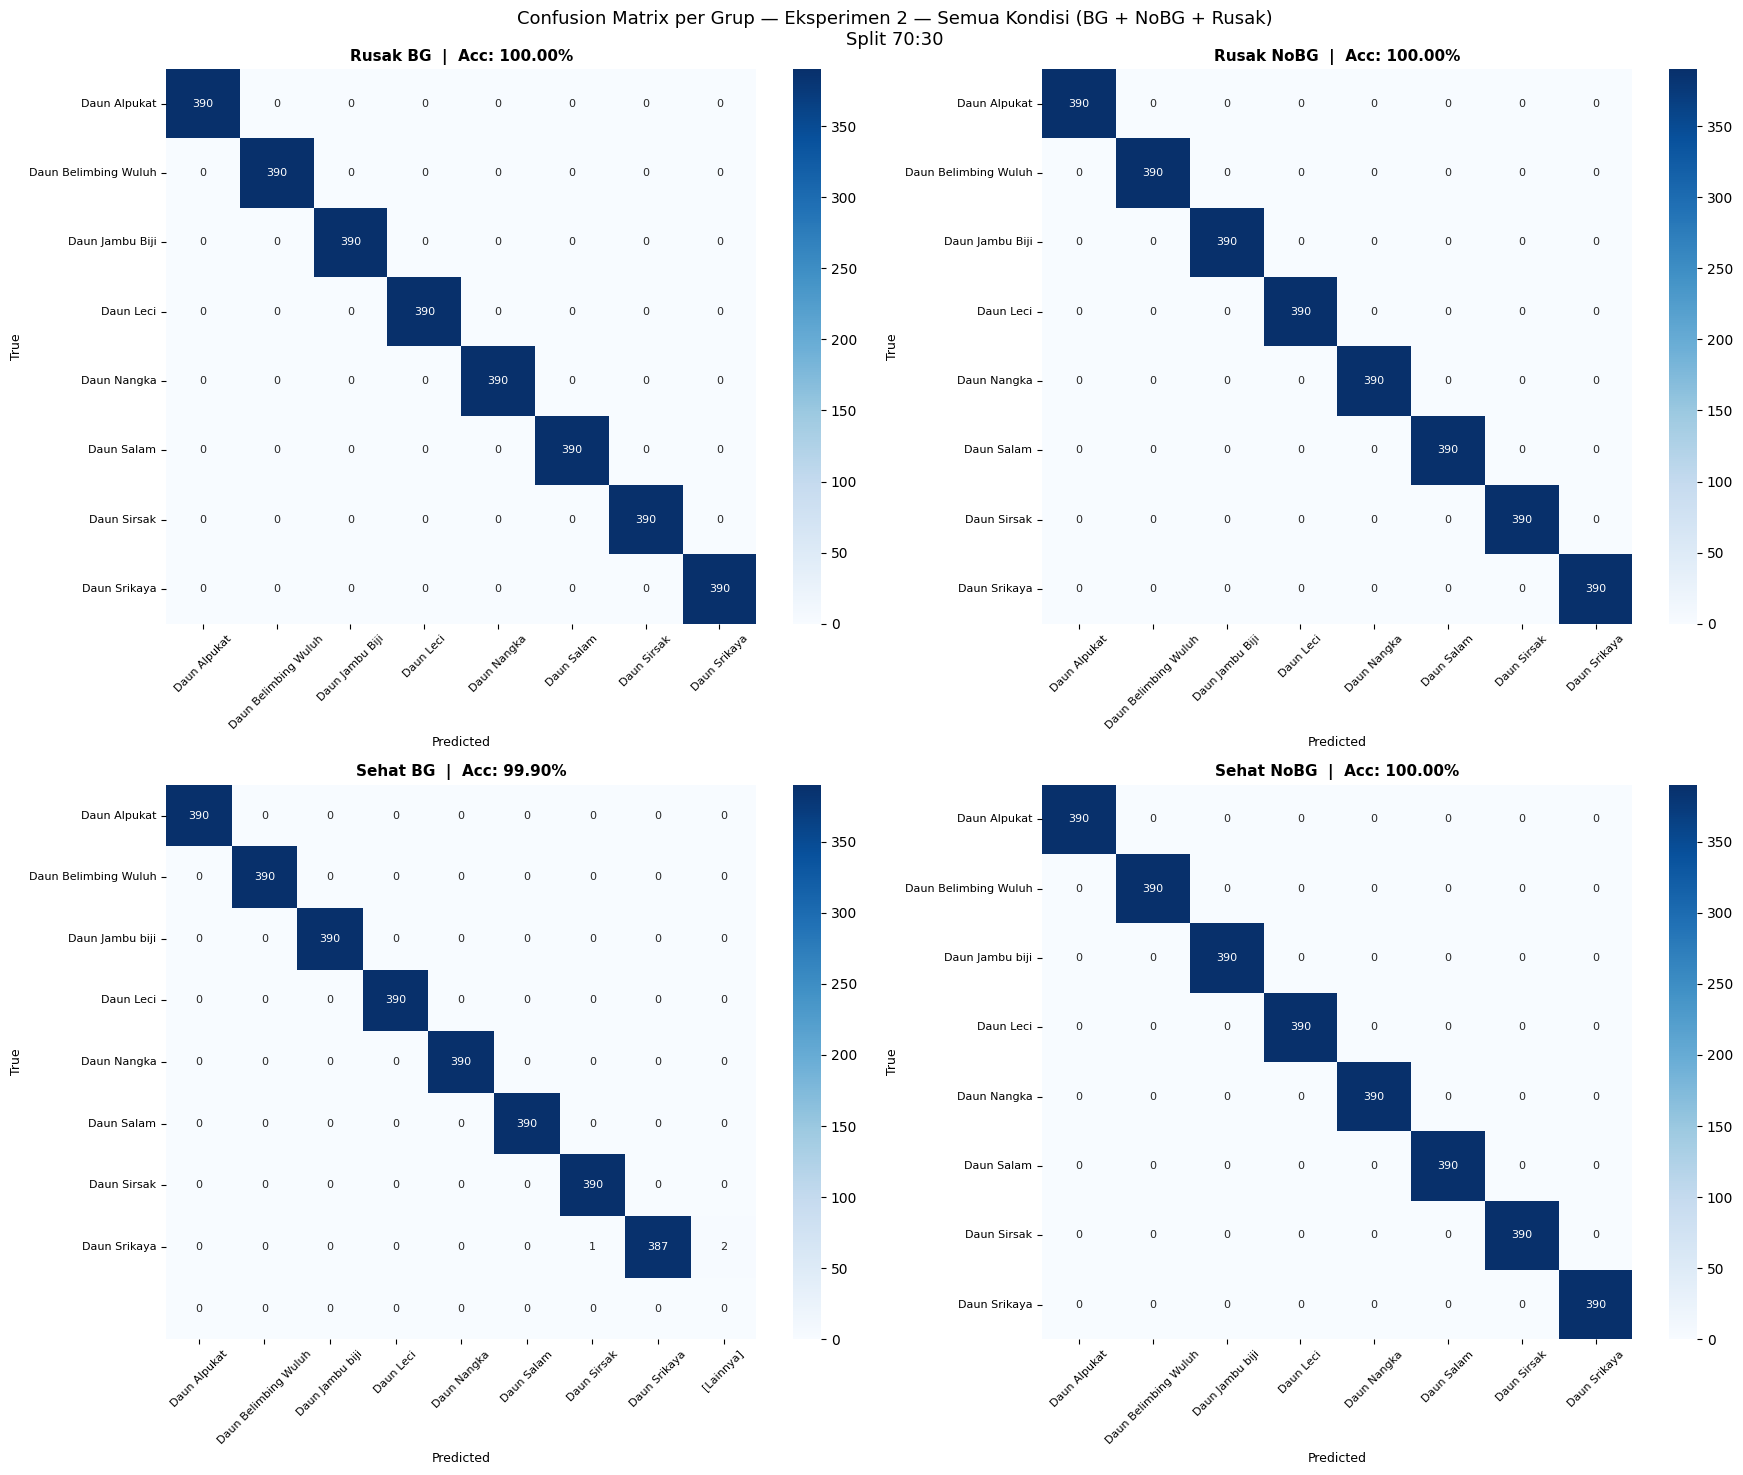

  Saved -> results_exp2_70.json


In [8]:
# Jalankan Eksperimen 2 (semua kondisi: sehat + rusak)
for ratio in [0.8, 0.7]:
    train_and_evaluate(
        exp_tag="exp2",
        exp_label="Eksperimen 2 — Semua Kondisi (BG + NoBG + Rusak)",
        include_rusak=True,
        split_ratio=ratio,
    )

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def train_and_evaluate(
    exp_tag: str,
    exp_label: str,
    include_rusak: bool,
    split_ratio: float,
):
    test_ratio = round(1.0 - split_ratio, 10)
    train_pct  = round(split_ratio * 100)
    test_pct   = 100 - train_pct
    label_str  = f"{train_pct}:{test_pct}"

    full_ds     = CombinedTaggedDataset(FINAL_NOBG, FINAL_BG, include_rusak=include_rusak)
    class_names = full_ds.classes
    num_classes = len(class_names)
    all_labels  = np.array([lbl for _, lbl in full_ds.samples])

    splitter = StratifiedShuffleSplit(n_splits=1, test_size=test_ratio, random_state=SEED)
    train_idx, val_idx = next(splitter.split(np.zeros(len(all_labels)), all_labels))

    train_loader = DataLoader(
        TransformWrapper(Subset(full_ds, train_idx), transform_train),
        batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
    )
    val_loader = DataLoader(
        TransformWrapper(Subset(full_ds, val_idx), transform_val),
        batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
    )

    print(f"\n{'='*60}")
    print(f"{exp_label.upper()} | Split {label_str}")
    print(f"Kelas: {num_classes} | Train: {len(train_idx)} | Val: {len(val_idx)}")

    model = models.shufflenet_v2_x1_0(
        weights=models.ShuffleNet_V2_X1_0_Weights.IMAGENET1K_V1
    )
    for p in model.parameters():
        p.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    model.to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.fc.parameters(), lr=LR)

    history = []
    start   = time.time()

    for epoch in range(EPOCHS):
        model.train()
        running_loss, train_correct, train_total = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            out  = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            running_loss  += loss.item()
            _, preds       = torch.max(out, 1)
            train_correct += (preds == y).sum().item()
            train_total   += y.size(0)
        avg_loss  = running_loss / len(train_loader)
        train_acc = train_correct / train_total

        model.eval()
        correct, total, val_loss = 0, 0, 0.0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                out      = model(x)
                val_loss += criterion(out, y).item()
                _, preds  = torch.max(out, 1)
                correct  += (preds == y).sum().item()
                total    += y.size(0)
        val_acc      = correct / total
        avg_val_loss = val_loss / len(val_loader)

        history.append({
            "epoch":      epoch + 1,
            "train_loss": round(avg_loss, 4),
            "train_acc":  round(train_acc, 4),
            "val_loss":   round(avg_val_loss, 4),
            "val_acc":    round(val_acc, 4),
        })
        print(f"  Epoch {epoch+1}/{EPOCHS}  train_loss={avg_loss:.4f}  train_acc={train_acc:.4f}"
              f"  val_loss={avg_val_loss:.4f}  val_acc={val_acc:.4f}")

    elapsed = time.time() - start
    print(f"  Selesai dalam {int(elapsed//60)}m {int(elapsed%60)}s")

    # ── Evaluasi akhir ────────────────────────────────────────────────────────
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in val_loader:
            _, preds = torch.max(model(x.to(DEVICE)), 1)
            y_true.extend(y.numpy())
            y_pred.extend(preds.cpu().numpy())

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1   = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

    print(f"\n  {'Metric':<12} {'Score':>8}")
    print(f"  {'-'*22}")
    print(f"  {'Accuracy':<12} {acc:>8.4f}")
    print(f"  {'Precision':<12} {prec:>8.4f}")
    print(f"  {'Recall':<12} {rec:>8.4f}")
    print(f"  {'F1-Score':<12} {f1:>8.4f}")

    best = max(history, key=lambda h: h["val_acc"])

    # ── Plot loss & akurasi ───────────────────────────────────────────────────
    ep_plot         = [0] + [h["epoch"]      for h in history]
    train_loss_plot = [history[0]["train_loss"]] + [h["train_loss"] for h in history]
    val_loss_plot   = [history[0]["val_loss"]]   + [h["val_loss"]   for h in history]
    train_acc_plot  = [0] + [h["train_acc"] for h in history]
    val_acc_plot    = [0] + [h["val_acc"]   for h in history]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(ep_plot, train_loss_plot, "r-o",  markersize=4, label="Train Loss")
    ax1.plot(ep_plot, val_loss_plot,   "g--s", markersize=4, label="Val Loss")
    ax1.plot(best["epoch"], best["val_loss"], "bo", markersize=8,
             label=f"Best Epoch {best['epoch']}")
    ax1.set_title(f"Loss — {exp_label}\nSplit {label_str}")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.legend(); ax1.grid(True)

    ax2.plot(ep_plot, train_acc_plot, "r-o",  markersize=4, label="Train Accuracy")
    ax2.plot(ep_plot, val_acc_plot,   "g--s", markersize=4, label="Val Accuracy")
    ax2.plot(best["epoch"], best["val_acc"], "bo", markersize=8,
             label=f"Best Epoch {best['epoch']} ({best['val_acc']:.2%})")
    ax2.set_title(f"Akurasi — {exp_label}\nSplit {label_str}")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
    ax2.set_ylim(0, 1.05)
    ax2.legend(); ax2.grid(True)

    plt.tight_layout()
    plt.savefig(RESULT_DIR / f"plot_{exp_tag}_{train_pct}.png", dpi=120, bbox_inches="tight")
    plt.show()

    # ── Confusion matrix terpisah per grup ───────────────────────────────────
    plot_split_cm(y_true, y_pred, class_names,
                  exp_tag, train_pct, exp_label, label_str)

    # ── Simpan model & JSON (UTF-8) ───────────────────────────────────────────
    torch.save(model.state_dict(), MODEL_DIR / f"shufflenet_{exp_tag}_{train_pct}.pth")
    json_path = RESULT_DIR / f"results_{exp_tag}_{train_pct}.json"
    json_path.write_text(json.dumps({
        "experiment":            exp_label,
        "tag":                   exp_tag,
        "split":                 label_str,
        "dataset_nobg":          str(FINAL_NOBG),
        "dataset_bg":            str(FINAL_BG),
        "include_rusak":         include_rusak,
        "num_classes":           num_classes,
        "class_names":           class_names,
        "epochs":                EPOCHS,
        "training_time_sec":     round(elapsed, 2),
        "accuracy":              round(acc, 4),
        "precision_weighted":    round(prec, 4),
        "recall_weighted":       round(rec, 4),
        "f1_weighted":           round(f1, 4),
        "best_epoch":            best["epoch"],
        "best_val_accuracy":     best["val_acc"],
        "final_train_accuracy":  history[-1]["train_acc"],
        "final_val_accuracy":    history[-1]["val_acc"],
        "classification_report": report,
        "training_history":      history,
    }, indent=2, ensure_ascii=False), encoding="utf-8")
    print(f"  Saved -> {json_path.name}")


# Jalankan Eksperimen 2 (semua kondisi: sehat + rusak)
for ratio in [0.7]:
    train_and_evaluate(
        exp_tag="exp2",
        exp_label="Eksperimen 2 — Semua Kondisi (BG + NoBG + Rusak)",
        include_rusak=True,
        split_ratio=ratio,
    )


EKSPERIMEN 2 — SEMUA KONDISI (BG + NOBG + RUSAK) | Split 70:30
Kelas: 32 | Train: 29120 | Val: 12480
  Epoch 1/100  train_loss=2.1386  train_acc=0.8021  val_loss=1.4422  val_acc=0.8933


## 7. Ringkasan Hasil

In [9]:
print("=== MODEL FILES ===")
for f in sorted(MODEL_DIR.glob("*.pth")):
    print(f"  {f.name}")

print("\n=== RESULT JSON ===")
for f in sorted(RESULT_DIR.glob("*.json")):
    try:
        text = f.read_text(encoding="utf-8")
    except UnicodeDecodeError:
        text = f.read_text(encoding="cp1252")
    data = json.loads(text)
    acc  = data.get("final_val_accuracy", data.get("best_val_accuracy", "N/A"))
    tag  = data.get("tag", f.stem)
    print(f"  {f.name:<45} val_acc={acc}  [{tag}]")

print("\n=== PLOTS ===")
for f in sorted(RESULT_DIR.glob("*.png")):
    print(f"  {f.name}")


=== MODEL FILES ===
  shufflenet_exp1_70.pth
  shufflenet_exp1_80.pth
  shufflenet_exp2_70.pth
  shufflenet_exp2_80.pth

=== RESULT JSON ===
  results_exp1_70.json                          val_acc=1.0  [exp1]
  results_exp1_80.json                          val_acc=1.0  [exp1]
  results_exp2_70.json                          val_acc=0.9998  [exp2]
  results_exp2_80.json                          val_acc=0.9996  [exp2]

=== PLOTS ===
  cm_split_exp1_70.png
  cm_split_exp1_80.png
  cm_split_exp2_70.png
  cm_split_exp2_80.png
  plot_exp1_70.png
  plot_exp1_80.png
  plot_exp2_70.png
  plot_exp2_80.png
